In [0]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import plotting
from scipy import stats
plt.style.use("ggplot")
import warnings
warnings.filterwarnings("ignore")
from scipy import stats

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os

# Any results you write to the current directory are saved as output.

In [0]:
# read data as pandas data frame
col_names=['ID', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']

data = pd.read_csv("wdbc.data",header=None, names=col_names, na_values="?")

#Drop ID col because we do not use it
data = data.drop('ID', axis = 1)

col = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']



In [3]:
# quick look to data
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<a id="1"></a> <br>
## Histogram
* How many times each value appears in dataset. This description is called the distribution of variable
* Most common way to represent distribution of varible is histogram that is graph which shows frequency of each value.
* Frequency = number of times each value appears
* Example: [1,1,1,1,2,2,2]. Frequency of 1 is four and frequency of 2 is three.

,feature,overlap_area,score
22,perimeter_worst,21.0,1
23,area_worst,38.0,2
7,concave points_mean,38.0,3
3,area_mean,44.0,4
27,concave points_worst,45.0,5
20,radius_worst,49.0,6
2,perimeter_mean,67.0,7
0,radius_mean,68.0,8
12,perimeter_se,77.0,9
28,symmetry_worst,83.0,10


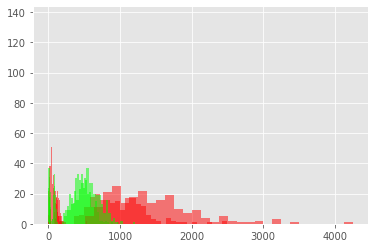

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

overlapping ={}
v = 0
for f in col:
  (n, bins, pl) = plt.hist(data[data["diagnosis"] == "M"][f],bins=30,fc = (1,0,0,0.5),label = "Malignant")
  ch_bins = bins[0:30]
  (n2, bins2, pl) = plt.hist(data[data["diagnosis"] == "B"][f],bins=30,fc = (0,1,0,0.5),label = "Bening")
  ch_bins2 = bins2[1:31]
  #print(f)
  #plt.xlabel("location")
  #plt.ylabel(f)

  #search intersection point
  intersect={}
  for inter in range(30):
    for inter2 in range(30):
      if (bins[inter]-bins2[inter2] < 0.0001):
        if(n[inter]-n2[inter2] <0.00001):
          intersect = [inter, inter2]

  w = int(intersect[0])  #intersect point in m line
  w2 = int(intersect[1])  #intersect point in b line
  area = 0
  area2 = 0
  for j in range(0,w):
    area = area+ n[j]
  for j in range(w2,30):
    area2 = area2+ n2[j]
  overlapping[v] = area + area2
  #print("overlap area: %8.2f\n" %overlapping[v])
  v = v+1

#print(overlapping)
H_feature = {}
H_value = {}
a = 0
for g in range(30):
  H_value[a] = overlapping[g]
  H_feature[a] = col[g] # selected features
  a = a +1

score = list(range(1,31))
df_overlap = pd.DataFrame(data={'feature' : H_feature, 'overlap_area' : H_value})
overlap_sort = df_overlap.sort_values(by=['overlap_area'], axis=0)
overlap_sort['score'] = score
overlap_sort

<a id="2"></a> <br>
## Outliers

In [5]:
data_bening = data[data["diagnosis"] == "B"]
data_malignant = data[data["diagnosis"] == "M"]

outlier_b = []
outlier_m = []

print("Bening")
print()
for i in col :
  desc = data_bening[i].describe()
  Q1 = desc[4]
  Q3 = desc[6]
  IQR = Q3-Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  print("%s" %i)
  print("Anything outside this range is an outlier: (", lower_bound ,",", upper_bound,")")
  data_bening[data_bening[i] < lower_bound][i]
  print("Outliers: ",data_bening[(data_bening[i] < lower_bound) | (data_bening[i] > upper_bound)][i].values)
  n = len(data_bening[(data_bening[i] < lower_bound) | (data_bening[i] > upper_bound)][i].values)
  outlier_b.append(n)
  print()

print("Malignant")
print()
for i in col :
  desc = data_malignant[i].describe()
  Q1 = desc[4]
  Q3 = desc[6]
  IQR = Q3-Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  print("%s" %i)
  print("Anything outside this range is an outlier: (", lower_bound ,",", upper_bound,")")
  data_malignant[data_malignant[i] < lower_bound][i]
  print("Outliers: ",data_malignant[(data_malignant[i] < lower_bound) | (data_malignant[i] > upper_bound)][i].values)
  n = len(data_malignant[(data_malignant[i] < lower_bound) | (data_malignant[i] > upper_bound)][i].values)
  outlier_m.append(n)
  print()

Bening

radius_mean
Anything outside this range is an outlier: ( 7.645000000000001 , 16.805 )
Outliers:  [ 6.981 16.84  17.85 ]

texture_mean
Anything outside this range is an outlier: ( 8.235 , 26.675000000000004 )
Outliers:  [27.08 33.81 27.85 28.21 28.23 30.72 29.29 28.2  26.99 28.14 29.97 28.06
 29.43 28.92 27.61 27.88 27.15 29.37]

perimeter_mean
Anything outside this range is an outlier: ( 48.02500000000002 , 108.94499999999998 )
Outliers:  [ 43.79 114.6   47.98  47.92]

area_mean
Anything outside this range is an outlier: ( 118.84999999999997 , 810.45 )
Outliers:  [880.2 838.1 992.1 819.8]

smoothness_mean
Anything outside this range is an outlier: ( 0.056600000000000025 , 0.12716 )
Outliers:  [0.1291  0.1634  0.1371  0.05263]

compactness_mean
Anything outside this range is an outlier: ( -0.00727499999999999 , 0.160445 )
Outliers:  [0.2233 0.1807 0.1676 0.1972 0.166  0.1836 0.2239 0.2204 0.1661]

concavity_mean
Anything outside this range is an outlier: ( -0.039209999999999995 

Count number of outliers and rank features

In [6]:
outlier_num = []
score = list(range(1,31))

for i in range(len(outlier_b)) :
  outlier = outlier_b[i] + outlier_m[i]
  outlier_num.append(outlier)

df_outlier = pd.DataFrame(data={'feature' : col, 'outlier' : outlier_num})
outlier_sort = df_outlier.sort_values(by=['outlier'], axis=0)
outlier_sort['score'] = score
outlier_sort


,feature,outlier,score
27,concave points_worst,4,1
22,perimeter_worst,5,2
20,radius_worst,5,3
0,radius_mean,6,4
2,perimeter_mean,7,5
4,smoothness_mean,7,6
24,smoothness_worst,7,7
3,area_mean,8,8
23,area_worst,10,9
28,symmetry_worst,10,10


<a id="3"></a> <br>
#### Box Plot of Outliers

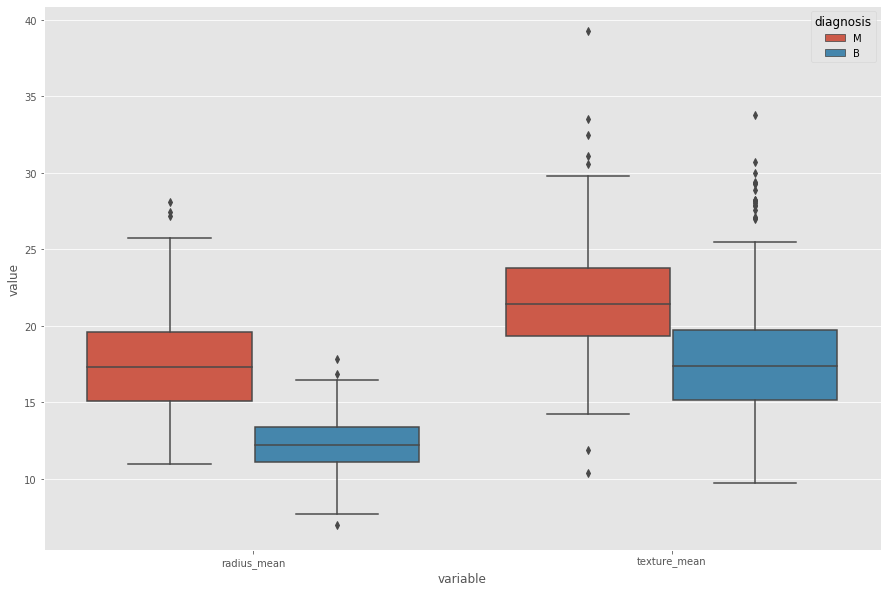

In [7]:
melted_data = pd.melt(data,id_vars = "diagnosis",value_vars = ['radius_mean', 'texture_mean'])
plt.figure(figsize = (15,10))
sns.boxplot(x = "variable", y = "value", hue="diagnosis",data= melted_data)
plt.show()

<a id="6"></a> <br>
## Effect size
* One of the summary statistics.
* It describes size of an effect. It is simple way of quantifying the difference between two groups.
* In an other saying, effect size emphasises the size of the difference
* Use cohen effect size
* Cohen suggest that if d(effect size)= 0.2, it is small effect size, d = 0.5 medium effect size, d = 0.8 large effect size.

In [8]:
es = []
for i in col :
  mean_diff = data_malignant[i].mean() - data_bening[i].mean()
  var_bening = data_bening[i].var()
  var_malignant = data_malignant[i].var()
  var_pooled = (len(data_bening)*var_bening +len(data_malignant)*var_malignant ) / float(len(data_bening)+ len(data_malignant))
  effect_size = mean_diff/np.sqrt(var_pooled)
  print("Effect size of %s: "%i, effect_size)
  es.append(effect_size)

print()
print("malignant and bening tumor are different in this features : ", es)

len(es)


Effect size of radius_mean:  2.2048585165041428
Effect size of texture_mean:  0.9422854105647376
Effect size of perimeter_mean:  2.2888607790811837
Effect size of area_mean:  2.0747649162508126
Effect size of smoothness_mean:  0.7930532000054346
Effect size of compactness_mean:  1.5342341463315043
Effect size of concavity_mean:  2.002761730832176
Effect size of concave points_mean:  2.5443378299184873
Effect size of symmetry_mean:  0.7229539203348531
Effect size of fractal_dimension_mean:  -0.026505879843043135
Effect size of radius_se:  1.4210283032950661
Effect size of texture_se:  -0.01714547202956752
Effect size of perimeter_se:  1.3809444086437457
Effect size of area_se:  1.3526665337896215
Effect size of smoothness_se:  -0.1386796144533211
Effect size of compactness_se:  0.632673364744096
Effect size of concavity_se:  0.5416734163797378
Effect size of concave points_se:  0.9227929258871297
Effect size of symmetry_se:  -0.013463091921153698
Effect size of fractal_dimension_se:  0.

30

Rank features with effect size

In [9]:
score = list(range(1,31))
df_es = pd.DataFrame(data={'feature' : col, 'effect size' : es})
es_sort = df_es.sort_values(by=['effect size'], axis=0, ascending=False)
es_sort['score'] = score
es_sort

,feature,effect size,score
27,concave points_worst,2.692321,1
22,perimeter_worst,2.597324,2
7,concave points_mean,2.544338,3
20,radius_worst,2.543017,4
2,perimeter_mean,2.288861,5
23,area_worst,2.229136,6
0,radius_mean,2.204859,7
3,area_mean,2.074765,8
6,concavity_mean,2.002762,9
26,concavity_worst,1.811712,10


<a id="4"></a> <br>
## Summary Statistics
* Mean
* Variance: spread of distribution
* Standart deviation square root of variance
* Lets look at summary statistics of bening tumor radiance mean

Detect features which have zero-variance (features that have the same/very similar value in all samples)

In [10]:
var=[]
var_b=[]
var_m=[]

for i in col :
  if round(data_bening[i].var()) == 0 :
    a = ["B", i]
    var_b.append(a)

for i in col :
  if round(data_malignant[i].var()) == 0 :
    a = ["M", i]
    var_m.append(a)

for k in range(len(var_m)) :
  for j in range(len(var_b)) :
    if var_m[k][1] == var_b[j][1] :
      var.append(var_m[k][1])

df_var = pd.DataFrame(data = {'variance = 0' : var})
df_var

,variance = 0
0,smoothness_mean
1,compactness_mean
2,concavity_mean
3,concave points_mean
4,symmetry_mean
5,fractal_dimension_mean
6,radius_se
7,texture_se
8,smoothness_se
9,compactness_se


<a id="8"></a> <br>
## Correlation

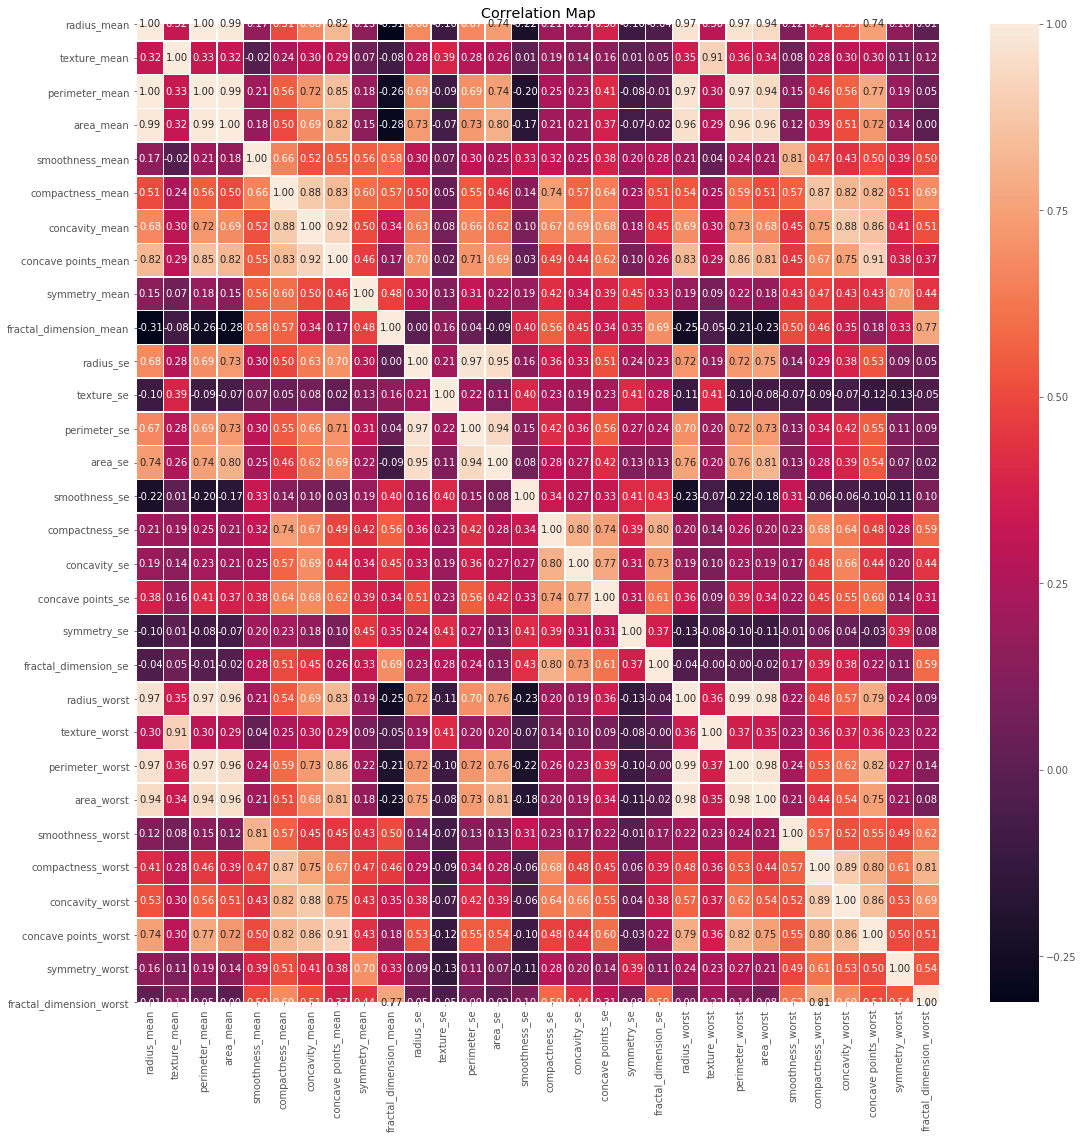

In [11]:
f,ax=plt.subplots(figsize = (18,18))
sns.heatmap(data.corr(),annot= True,linewidths=0.5,fmt = ".2f",ax=ax)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Correlation Map')
plt.savefig('cor_graph.png')
plt.show()

* Huge matrix that includes a lot of numbers
* The range of this numbers are -1 to 1. 
* Meaning of 1 is two variable are positively correlated with each other like radius mean and area mean
* Meaning of zero is there is no correlation between variables like radius mean and fractal dimension se
* Meaning of -1 is two variables are negatively correlated with each other like radius mean and fractal dimension mean.Actually correlation between of them is not -1, it is -0.3 but the idea is that if sign of correlation is negative that means that there is negative correlation.

Select feature (correlation > 0.9)

In [12]:
correlation = []

for i in col :
  for j in col :
    corr = data[i].corr(data[j])
    if i != j :
      correlation.append(corr)

corr_pair_1 = []
corr_pair_2 = []

for i in col :
  for j in col :
    if i != j :
      corr_pair_1.append(i)
      corr_pair_2.append(j)

df_corr = pd.DataFrame(data={'feature_1' : corr_pair_1, 'feature_2' : corr_pair_2, 'correlation' : correlation})
corr_sort = df_corr.sort_values(by=['correlation'], axis=0, ascending=False)

for i in range(435) :
  a = 2*(i+1) - 1
  corr_sort = corr_sort.drop(a, 0)
 
corr_sort_n = corr_sort[0:21]
corr_sort_n


,feature_1,feature_2,correlation
58,perimeter_mean,radius_mean,0.997855
658,perimeter_worst,radius_worst,0.993708
2,radius_mean,area_mean,0.987357
60,perimeter_mean,area_mean,0.986507
602,radius_worst,area_worst,0.984015
660,perimeter_worst,area_worst,0.977578
358,perimeter_se,radius_se,0.972794
640,perimeter_worst,perimeter_mean,0.970387
580,radius_worst,radius_mean,0.969539
582,radius_worst,perimeter_mean,0.969476


<a id="9"></a> <br>
## Covariance
* Covariance is measure of the tendency of two variables to vary together
* So covariance is maximized if two vectors are identical
* Covariance is zero if they are orthogonal.
* Covariance is negative if they point in opposite direction
* Lets look at covariance between radius mean and area mean. Then look at radius mean and fractal dimension se


In [0]:
#np.cov(data.radius_mean,data.area_mean)
#print("Covariance between radius mean and area mean: ",data.radius_mean.cov(data.area_mean))
#print("Covariance between radius mean and fractal dimension se: ",data.radius_mean.cov(data.fractal_dimension_se))

covariance = []
for i in col :
  for j in col :
    cov = data[i].cov(data[j])
    if (i != j) :
      covariance.append(cov)
    #print("Covariance between %s "%i +"and %s is : "%j, cov)

Select feature (covariance > 100)

In [14]:
cov_pair_1 = []
cov_pair_2 = []
for i in range(len(col)) :
  for j in range(len(col)) :
    if (col[i] != col[j]) :
      cov_pair_1.append(col[i])
      cov_pair_2.append(col[j])

df_cov = pd.DataFrame(data={'feature_1' : cov_pair_1, 'feature_2' : cov_pair_2, 'covariance' : covariance})
cov_sort = df_cov.sort_values(by=['covariance'], axis=0, ascending=False)

for i in range(435) :
  a = 2*(i+1) - 1
  cov_sort = cov_sort.drop(a, 0)

cov_sort_n = cov_sort[0:26]
cov_sort_n

,feature_1,feature_2,covariance
670,area_worst,area_mean,192192.557633
680,area_worst,area_se,21015.970960
660,perimeter_worst,area_worst,18702.869991
80,perimeter_mean,area_worst,13026.148359
380,area_se,area_mean,12808.517580
108,area_mean,perimeter_worst,11341.789807
60,perimeter_mean,area_mean,8435.772345
602,radius_worst,area_worst,2707.850532
22,radius_mean,area_worst,1888.227223
106,area_mean,radius_worst,1637.521341


##Feature Selection

Ranking of features based on histogram, outliers, effect size

In [15]:
ols = overlap_sort.sort_index()
ous = outlier_sort.sort_index()
ess = es_sort.sort_index()

feature = ess.feature
score = ols.score + ous.score + ess.score

total_score = pd.DataFrame(data={'feature' : feature, 'total score' : score})

ts_sort = total_score.sort_values(by=['total score'], axis=0)
ts_sort = ts_sort.reset_index(drop=True)
ts_sort

,feature,total score
0,perimeter_worst,5
1,concave points_worst,7
2,radius_worst,13
3,perimeter_mean,17
4,area_worst,17
5,radius_mean,19
6,area_mean,20
7,concave points_mean,31
8,radius_se,36
9,symmetry_worst,38


Delete features based on variance of each features

In [16]:
import copy
first_delete = copy.copy(ts_sort)
f_delete_index = []

for i in range(30) :
  for j in range(20) :
    if ts_sort['feature'][i] == df_var['variance = 0'][j] :
      f_delete_index.append(i)

first_delete = first_delete.drop(f_delete_index, 0)

first_delete = first_delete.reset_index(drop=True)
first_delete

,feature,total score
0,perimeter_worst,5
1,radius_worst,13
2,perimeter_mean,17
3,area_worst,17
4,radius_mean,19
5,area_mean,20
6,perimeter_se,44
7,texture_worst,46
8,area_se,52
9,texture_mean,68


select feature which has the most number of related features

In [17]:
corr_freq_1 = corr_sort_n['feature_1'].value_counts().to_frame()
corr_freq_2 = corr_sort_n['feature_2'].value_counts().to_frame()

cov_freq_1 = cov_sort_n['feature_1'].value_counts().to_frame()
cov_freq_2 = cov_sort_n['feature_2'].value_counts().to_frame()

corr_freq_1_del = []
corr_freq_2_del = []
cov_freq_1_del = []
cov_freq_2_del = []

for i in range(len(corr_freq_1)) :
  if corr_freq_1['feature_1'][i] == corr_freq_1.max().values[0] :
    corr_freq_1_del.append(corr_freq_1.index[i])

for i in range(len(corr_freq_2)) :
  if corr_freq_2['feature_2'][i] == corr_freq_2.max().values[0] :
    corr_freq_2_del.append(corr_freq_2.index[i])

for i in range(len(cov_freq_1)) :
  if cov_freq_1['feature_1'][i] == cov_freq_1.max().values[0] :
    cov_freq_1_del.append(cov_freq_1.index[i])

for i in range(len(cov_freq_2)) :
  if cov_freq_2['feature_2'][i] == cov_freq_2.max().values[0] :
    cov_freq_2_del.append(cov_freq_2.index[i])

corr_del_base = corr_freq_1_del + corr_freq_2_del
cov_del_base = cov_freq_1_del + cov_freq_2_del
delete_base = corr_del_base + cov_del_base
delete_base = list(set(delete_base))

print(corr_freq_1_del)
print(corr_freq_2_del)
print(cov_freq_1_del)
print(cov_freq_2_del)

delete_base

['perimeter_worst']
['area_worst']
['perimeter_worst', 'area_worst', 'area_mean']
['area_worst']


['area_worst', 'area_mean', 'perimeter_worst']

delete features related to **perimeter_worst, area_worst, area_mean**

In [18]:
import copy

delete_corr_1 = []
delete_corr_2 = []
delete_cov_1 = []
delete_cov_2 = []

for i in range(21) :
  for j in range(len(corr_freq_1_del)) :
    if corr_sort_n.feature_1.values[i] == corr_freq_1_del[j] :
      if corr_sort_n.feature_2.values[i] not in delete_base :
        delete_corr_1.append(corr_sort_n.feature_2.values[i])

for i in range(21) :
  for j in range(len(corr_freq_2_del)) : 
    if corr_sort_n.feature_2.values[i] == corr_freq_2_del[j] :
      if corr_sort_n.feature_1.values[i] not in delete_base :
        delete_corr_2.append(corr_sort_n.feature_1.values[i])

for i in range(26) :
  if cov_sort_n.feature_1.values[i] == 'area_mean' :
    if cov_sort_n.feature_2.values[i] not in delete_base :
      delete_cov_1.append(cov_sort_n.feature_2.values[i])

for i in range(26) :
  for j in range(len(cov_freq_2_del)) : 
    if cov_sort_n.feature_2.values[i] == cov_freq_2_del[j] :
      if cov_sort_n.feature_1.values[i] not in delete_base :
        delete_cov_2.append(cov_sort_n.feature_1.values[i])

print(delete_corr_1)
print(delete_corr_2)
print(delete_cov_1)
print(delete_cov_2)

delete_feature = list(set(delete_corr_1 + delete_corr_2 + delete_cov_1 + delete_cov_2))
delete_feature

second_delete = copy.copy(first_delete)
s_delete_index = []

for i in range(len(first_delete)) :
  for j in range(len(delete_feature)) :
    if first_delete.feature.values[i] == delete_feature[j] :
      s_delete_index.append(i)

second_delete = second_delete.drop(s_delete_index, 0)
selected_features = second_delete.reset_index(drop=True)

print("5 selected features")
selected_features

['radius_worst', 'perimeter_mean', 'radius_mean']
['radius_worst', 'perimeter_mean', 'radius_mean']
['radius_worst', 'perimeter_se', 'texture_mean']
['perimeter_mean', 'radius_worst', 'radius_mean', 'perimeter_se', 'radius_se']
5 selected features


,feature,total score
0,perimeter_worst,5
1,area_worst,17
2,area_mean,20
3,texture_worst,46
4,area_se,52


#Data Analysis

In [19]:
# y includes our labels and x includes our features
y = data.diagnosis                          # M or B 
list = ['diagnosis']

X = data.drop(list, axis = 1)
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Number of Benign:  357
Number of Malignant :  212


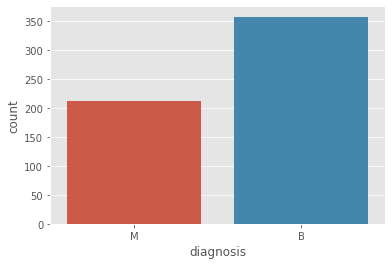

In [20]:
ax = sns.countplot(y,label="Count")       # M = 212, B = 357
B, M = y.value_counts()
print('Number of Benign: ',B)
print('Number of Malignant : ',M)

#Apply selected features

Selection is based on statistic information

In [25]:
sel_features = ['perimeter_worst', 'area_worst', 'area_mean', 'texture_worst', 'area_se']
an_data = X[sel_features]
an_data

,perimeter_worst,area_worst,area_mean,texture_worst,area_se
0,184.60,2019.0,1001.0,17.33,153.40
1,158.80,1956.0,1326.0,23.41,74.08
2,152.50,1709.0,1203.0,25.53,94.03
3,98.87,567.7,386.1,26.50,27.23
4,152.20,1575.0,1297.0,16.67,94.44
...,...,...,...,...,...
564,166.10,2027.0,1479.0,26.40,158.70
565,155.00,1731.0,1261.0,38.25,99.04
566,126.70,1124.0,858.1,34.12,48.55
567,184.60,1821.0,1265.0,39.42,86.22


#split data to training set and test set

####split data without removing outliers

In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(an_data, y, test_size=0.2, random_state=0)

#Build Model / Result

###Random forest

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_rf = RandomForestClassifier(n_estimators=10)      
clr_rf = clf_rf.fit(X_train,y_train)
y_pred = clf_rf.predict(X_test)
ac_rf = accuracy_score(y_test,y_pred)
cm = pd.DataFrame(confusion_matrix(y_test, y_pred), columns=["B", "M"], index=["B", "M"])

print("Random Forest Accuracy : %0.2f" % ac_rf)
cm

Random Forest Accuracy : 0.96


,B,M
B,64,3
M,1,46


###SVM

In [28]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_svm = SVC(kernel  = "linear")   
clr_svm = clf_svm.fit(X_train,y_train)
y_pred = clf_svm.predict(X_test)
ac_svm = accuracy_score(y_test,y_pred)
cm = pd.DataFrame(confusion_matrix(y_test, y_pred), columns=["B", "M"], index=["B", "M"])
print("SVM Accuracy : %0.2f" % ac_svm)
cm

SVM Accuracy : 0.93


,B,M
B,62,5
M,3,44
